<a href="https://colab.research.google.com/github/aysearyavilgenoglu/IAT_461_Lab_Tasks/blob/main/EDA_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Meridian Coworking — First-Year Member Renewal Prediction
## Milestone 2: Exploratory Data Analysis

**Project goal:** Predict which currently active, first-year Meridian Coworking members will
fail to renew their membership at the one-year mark, using behavioral signals from their
first 90 days (check-ins, session length, meeting room bookings, weekend usage, support
tickets, referral status). This is a supervised binary classification problem.

**Stakeholder:** Head of Member Success, who will use risk scores to prioritize proactive
retention outreach to at-risk members before their renewal date.

This notebook covers the EDA and high-level dataset overview expected at this stage of the
project timeline.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/IAT461_Milestone2/meridian_members.csv')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print(df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(900, 11)


,member_id,location,membership_type,checkins_first_90d,avg_session_hours,meeting_room_bookings_first_90d,weekend_usage_ratio,preferred_time_slot,support_tickets_first_90d,referred_by_existing_member,renewed_year1
0,1,Yaletown,hot-desk,23,3.6,3,0.12,afternoon,2,1,1
1,2,Downtown Core,hot-desk,23,5.2,3,0.09,morning,0,0,1
2,3,Downtown Core,hot-desk,27,3.8,2,0.02,afternoon,1,1,1
3,4,Kitsilano,dedicated-desk,19,3.5,4,0.22,afternoon,3,0,0
4,5,Yaletown,hot-desk,27,2.8,2,0.19,morning,1,1,1


## 1. Dataset Overview

900 members, 11 columns (10 features + 1 target: `renewed_year1`). The dataset is
synthetically generated (seed=42) via `generate_data.py`, included in this repo, so the
generation logic can be inspected or reproduced.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   member_id                        900 non-null    int64  
 1   location                         900 non-null    object 
 2   membership_type                  900 non-null    object 
 3   checkins_first_90d               900 non-null    int64  
 4   avg_session_hours                900 non-null    float64
 5   meeting_room_bookings_first_90d  900 non-null    int64  
 6   weekend_usage_ratio              900 non-null    float64
 7   preferred_time_slot              900 non-null    object 
 8   support_tickets_first_90d        900 non-null    int64  
 9   referred_by_existing_member      900 non-null    int64  
 10  renewed_year1                    900 non-null    int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 77.5+ KB


In [8]:
df.isna().sum()


,0
member_id,0
location,0
membership_type,0
checkins_first_90d,0
avg_session_hours,0
meeting_room_bookings_first_90d,0
weekend_usage_ratio,0
preferred_time_slot,0
support_tickets_first_90d,0
referred_by_existing_member,0


No missing values, since this is a clean synthetic dataset. In a real-world version of
this dataset we would expect missingness in fields like `support_tickets_first_90d` or
`preferred_time_slot` (e.g., inferred fields that require enough check-in history to compute).


In [9]:
df.describe()


,member_id,checkins_first_90d,avg_session_hours,meeting_room_bookings_first_90d,weekend_usage_ratio,support_tickets_first_90d,referred_by_existing_member,renewed_year1
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,450.500000,25.051111,4.494000,2.923333,0.196033,1.234444,0.294444,0.623333
std,259.951919,5.143075,1.544608,1.564238,0.133418,1.147388,0.456046,0.484820
min,1.000000,11.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,225.750000,21.000000,3.400000,2.000000,0.090000,0.000000,0.000000,0.000000
50%,450.500000,25.000000,4.500000,3.000000,0.170000,1.000000,0.000000,1.000000
75%,675.250000,28.000000,5.500000,4.000000,0.280000,2.000000,1.000000,1.000000
max,900.000000,43.000000,9.400000,9.000000,0.740000,7.000000,1.000000,1.000000


## 2. Target Variable: `renewed_year1`

This is the variable we are trying to predict. Understanding its balance is important because
class imbalance affects both modeling choices (e.g., class weighting) and evaluation metric
choice (the client proposal specifies recall on the non-renewal class is the priority).


renewed_year1
1    561
0    339
Name: count, dtype: int64

Overall renewal rate: 62.3%


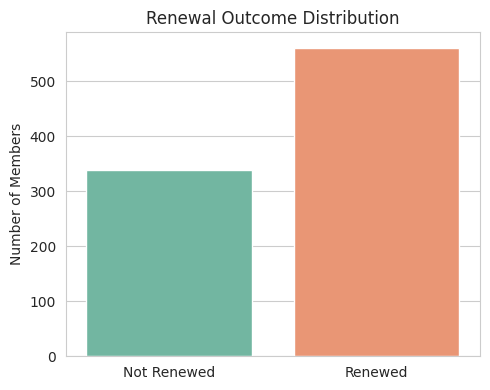

In [10]:
renewal_counts = df['renewed_year1'].value_counts()
renewal_rate = df['renewed_year1'].mean()

print(renewal_counts)
print(f"\nOverall renewal rate: {renewal_rate:.1%}")

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='renewed_year1', hue='renewed_year1', palette='Set2', legend=False)
plt.xticks([0,1], ['Not Renewed', 'Renewed'])
plt.title('Renewal Outcome Distribution')
plt.ylabel('Number of Members')
plt.xlabel('')
plt.tight_layout()
plt.show()


**Observation:** About 62% of members renewed in year 1, meaning  about 38% did not. This is a moderate class imbalance, not severe, but still worth keeping in mind for modeling (e.g., stratified train/test split, class weighting, and prioritizing recall on the minority "not renewed" class as specified in the success criteria).


## 3. Categorical Features

Distribution of `location`, `membership_type`, and `preferred_time_slot`.


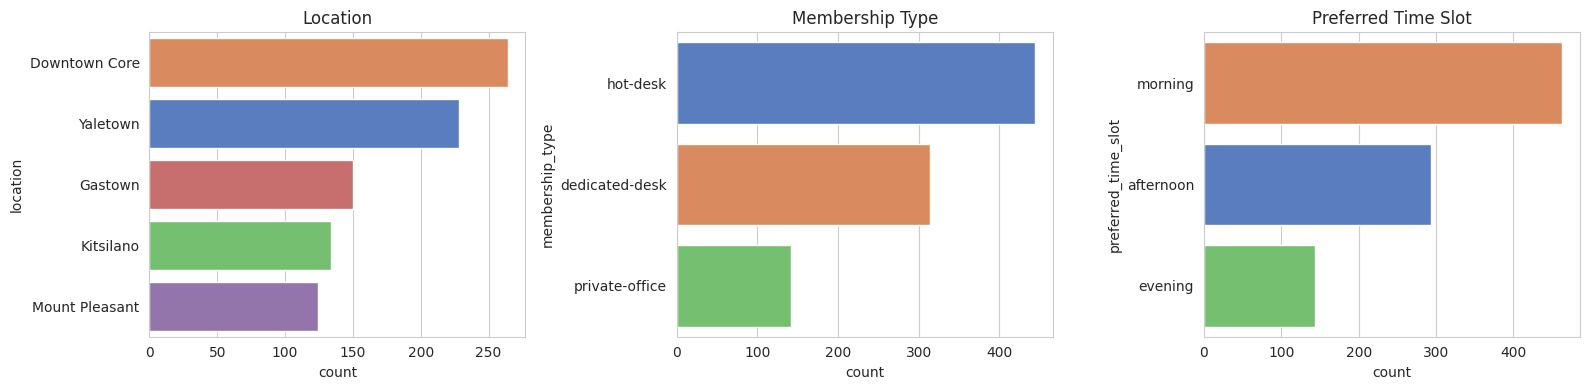

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df, y='location', order=df['location'].value_counts().index, ax=axes[0], hue='location', palette='muted', legend=False)
axes[0].set_title('Location')

sns.countplot(data=df, y='membership_type', order=df['membership_type'].value_counts().index, ax=axes[1], hue='membership_type', palette='muted', legend=False)
axes[1].set_title('Membership Type')

sns.countplot(data=df, y='preferred_time_slot', order=df['preferred_time_slot'].value_counts().index, ax=axes[2], hue='preferred_time_slot', palette='muted', legend=False)
axes[2].set_title('Preferred Time Slot')

plt.tight_layout()
plt.show()


**Observation:** Downtown Core and Yaletown are the largest locations; Mount Pleasant and Kitsilano have noticeably fewer members. This matches the constraint noted in the client
proposal: location is not evenly represented, so location-based patterns should be interpreted cautiously, especially for the smaller locations.
Hot-desk is the most common membership type (about half of all members), and morning is the most common preferred check-in time.


## 4. Renewal Rate by Categorical Feature

Rather than just looking at counts, we look at how the renewal rate itself varies across categories. This is more directly relevant to the prediction problem.


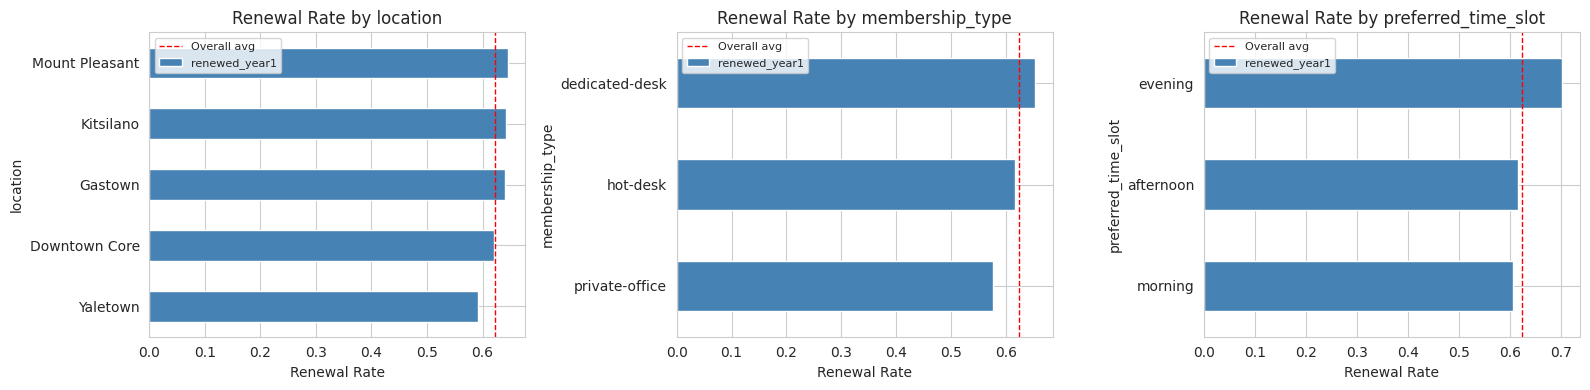

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['location', 'membership_type', 'preferred_time_slot']):
    rates = df.groupby(col)['renewed_year1'].mean().sort_values()
    rates.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Renewal Rate by {col}')
    ax.set_xlabel('Renewal Rate')
    ax.axvline(df['renewed_year1'].mean(), color='red', linestyle='--', linewidth=1, label='Overall avg')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**Observation:** Renewal rate is fairly similar across locations (roughly 59-65%), so location alone does not appear to be a strong predictor on its own.
Membership type shows a mild pattern (dedicated-desk members renew slightly more than private-office members).
Preferred time slot shows evening members renewing more often than morning/afternoon members, though this group is also the smallest, so the estimate is noisier.


## 5. Numeric Behavioral Features

Distribution of the first-90-day engagement signals, split by renewal outcome.


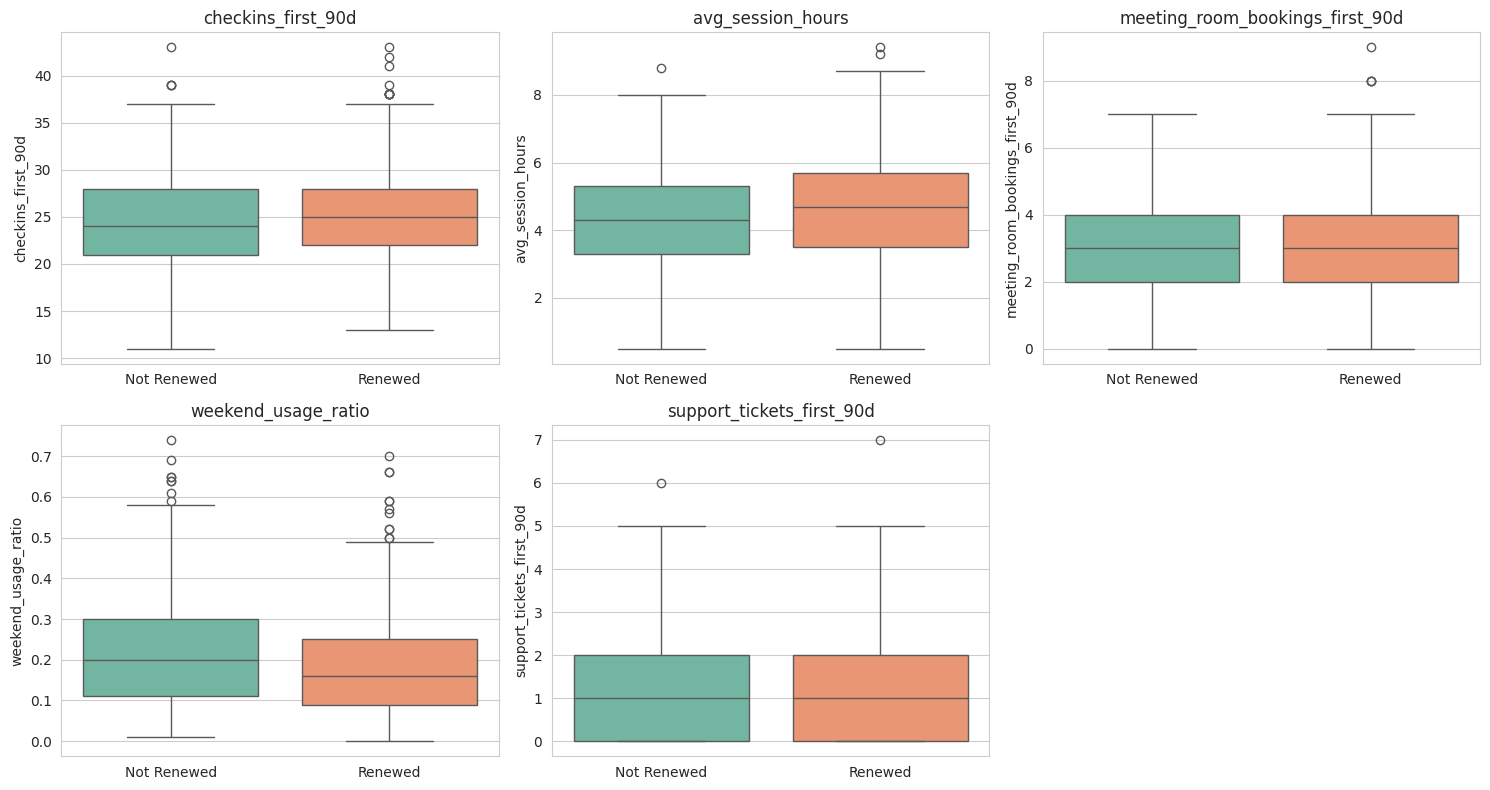

In [13]:
numeric_features = ['checkins_first_90d', 'avg_session_hours',
                     'meeting_room_bookings_first_90d', 'weekend_usage_ratio',
                     'support_tickets_first_90d']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, x='renewed_year1', y=col, hue='renewed_year1', ax=axes[i], palette='Set2', legend=False)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Not Renewed', 'Renewed'])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


**Observation:** `weekend_usage_ratio` shows the clearest visual separation: members who did not renew tend to have a higher proportion of weekend visits. This is consistent with the data generation logic (weekend usage has a negative coefficient in the underlying renewal
probability model), and intuitively makes sense: a member who mostly uses the space evenings or weekends may treat it as a lower-commitment, less central part of their routine.
`meeting_room_bookings_first_90d` also shows a mild positive separation for renewed members.


## 6. Referral Status and Renewal

The client proposal explicitly includes `referred_by_existing_member` as a feature. Referred
members may already be pre-screened for fit (an existing member is unlikely to refer someone
who won't enjoy the space), so we check this relationship directly.


                  mean  count
Not Referred  0.551181    635
Referred      0.796226    265


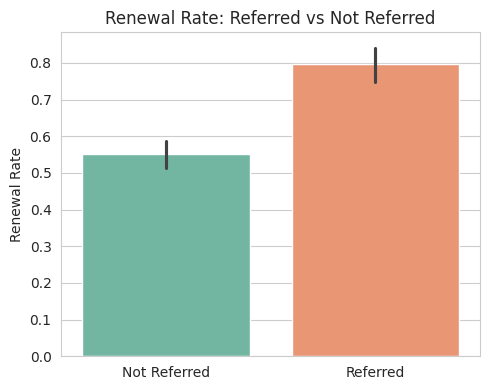

In [14]:
referral_rates = df.groupby('referred_by_existing_member')['renewed_year1'].agg(['mean', 'count'])
referral_rates.index = ['Not Referred', 'Referred']
print(referral_rates)

plt.figure(figsize=(5,4))
sns.barplot(data=df, x='referred_by_existing_member', y='renewed_year1', hue='referred_by_existing_member', palette='Set2', legend=False)
plt.xticks([0,1], ['Not Referred', 'Referred'])
plt.ylabel('Renewal Rate')
plt.xlabel('')
plt.title('Renewal Rate: Referred vs Not Referred')
plt.tight_layout()
plt.show()


**Observation:** This is the single clearest pattern in the dataset. Referred members renew at about 80%, compared to about 55% for non-referred members. A roughly 25 percentage point gap. This suggests `referred_by_existing_member` will likely be one of the strongest
predictors in the eventual model, and is also actionable for the business (e.g., incentivizing referrals could plausibly improve retention, beyond just being a useful prediction signal).


## 7. Correlation with Target

A quick linear correlation check across all numeric features against the target, to get an
initial sense of feature relevance before modeling.


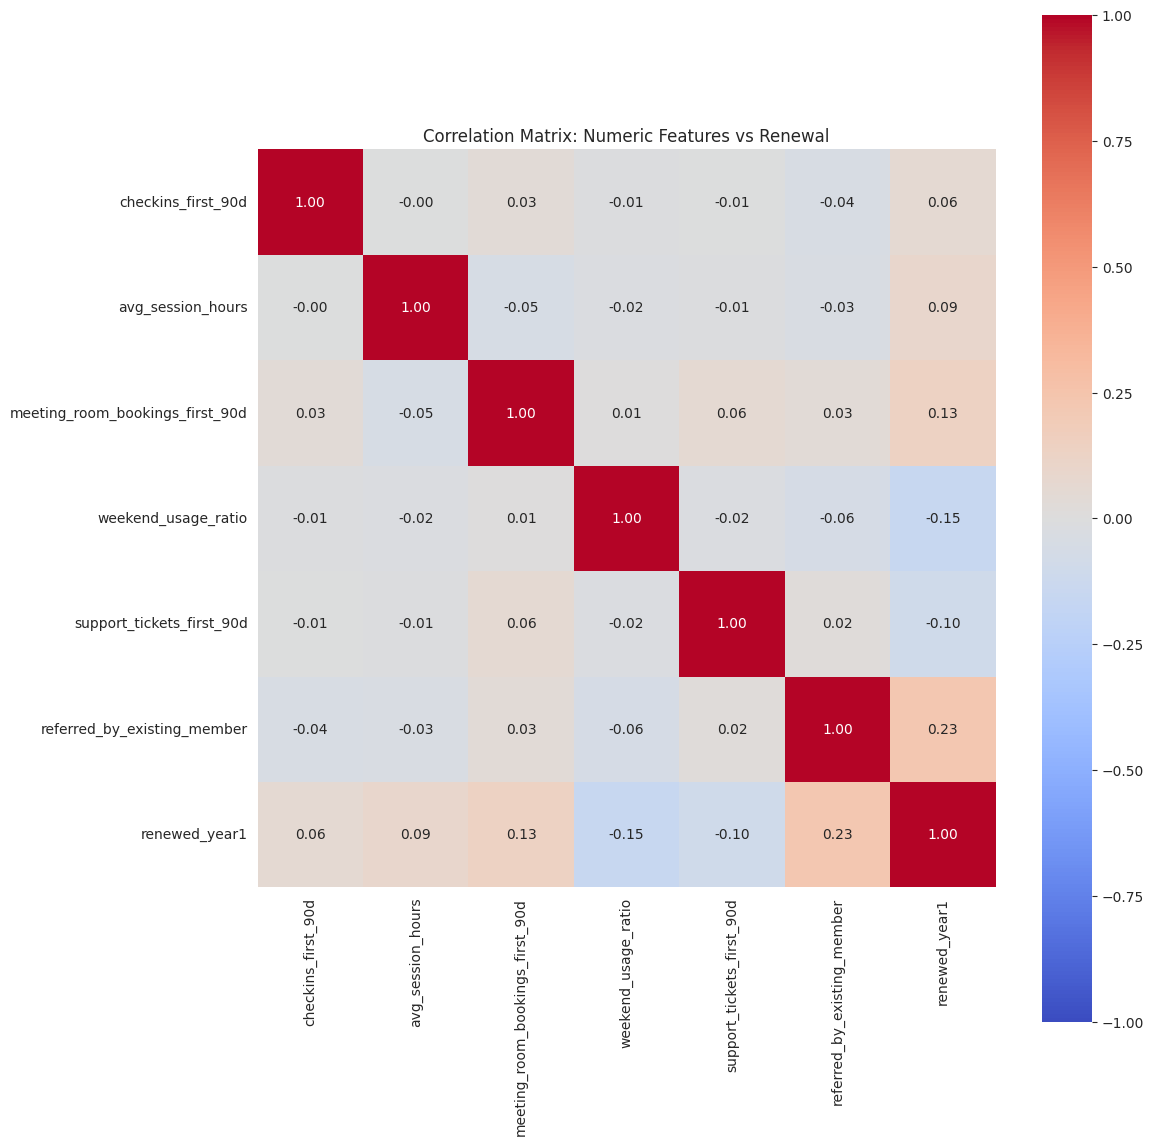

In [17]:
numeric_cols = ['checkins_first_90d', 'avg_session_hours', 'meeting_room_bookings_first_90d',
                 'weekend_usage_ratio', 'support_tickets_first_90d', 'referred_by_existing_member']

corr = df[numeric_cols + ['renewed_year1']].corr()

plt.figure(figsize=(12,12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix: Numeric Features vs Renewal')
plt.tight_layout()
plt.show()


**Observation:** `referred_by_existing_member` has the strongest linear correlation with the target (0.23), followed by `weekend_usage_ratio` (negative, -0.15) and `meeting_room_bookings_first_90d` (0.13).`checkins_first_90d` and `avg_session_hours` show weak linear correlation individually, which is a useful finding: it suggests raw check-in volume alone won't carry the model, and that a nonlinear model (e.g., tree-based) or feature interactions may be worth exploring at the modeling stage, since these correlations only capture linear relationships.


## 8. Summary of EDA Findings

- **Class balance:** ~62% renewed / ~38% not renewed > moderate imbalance, will use stratified splitting and prioritize recall on the non-renewal class per the success criteria.
- **No missing data**, since the dataset is synthetic; a real-world version would likely need missing-value handling. (Should I add some missing value on this dataset)
- **Location is unevenly represented** (Downtown Core and Yaletown are largest), consistent with the constraint noted in the client proposal.
location-based patterns should be interpreted cautiously.
- **Strongest single signal so far:** referral status. Referred members renew at a meaningfully higher rate.
- **Weekend usage ratio** shows a negative relationship with renewal- worth keeping as a feature and potentially exploring interactions with membership type.
- **Weak individual linear correlations** for check-ins and session length suggest these features may matter more in combination (interactions) than alone, motivating the use of a model capable of capturing nonlinearity (e.g., logistic regression with engineered interaction terms, or a tree-based model like Random Forest) at the next stage.

## Next Steps (Modeling Stage)

- Train/test split with stratification on `renewed_year1`
- Baseline logistic regression model with interpretable coefficients
- Compare against a tree-based model (Random Forest / Gradient Boosting) for nonlinear patterns
- Evaluate primarily on recall for the non-renewal class, per the client's stated success criteria, alongside precision and AUC
- Encode categorical features (`location`, `membership_type`, `preferred_time_slot`) likely one-hot encoding given the low cardinality of each
